# Deep Q-Learning Sensor Placement

Harris corner detection places outer sensors first. `SensorDRL` then trains a DQN policy that sequentially places inner sensors.

In [1]:
import importlib
import Analysis.visualization as visualization
from Analysis.visualization import VisualTool
from Engine.map_loader import MapLoader
from Engine.masks import layer_map
from InnerDeployment.DRL.main import SensorDRL
from OuterDeployment.HarrisCorner import HarrisCorner

importlib.reload(visualization)
VisualTool = visualization.VisualTool

In [ ]:
vis = VisualTool(show=True, size=(10, 10), save=True, dpi=100, save_dir="__RESULTS__/_plots", save_title=False)

### Overview of Construction site map

In [ ]:
map_data = MapLoader().load("gangjin/full")

In [ ]:
vis.showMapOverview(map_data=map_data, title="Gangjin Construction Site Overview", filename="construction_map_overview")

Installable map
<br><sub> A binary grid mask that defines physically feasible sensor deployment locations on the site. </sub>

In [ ]:
installable_layer = layer_map(map_data, keep_values=[2])
vis.showMapOverview(
    map_data=installable_layer,
    title="Installable Area Overview",
    filename="installable_map_overview",
    zone_style="installable",
)

Uninstallable map
<br><sub>Regions excluded from sensor deployment due to safety, accessibility, or operational constraints <br>(e.g., equipment routes, waterlogged areas, vegetation, and offices).</sub>

In [ ]:
road_layer = layer_map(map_data, keep_values=[3])
vis.showMapOverview(
    map_data=road_layer,
    title="Restricted Area Overview",
    filename="restricted_map_overview",
    zone_style="restricted",
)

Jobsite area
<br><sub>The coverage target area for sensor deployment, defined as the union of installable and non-installable regions.</sub>

In [ ]:
jobsite_layer = layer_map(map_data, keep_values=[2, 3])
vis.showMapOverview(
    map_data=jobsite_layer,
    title="Jobsite Area Overview",
    filename="jobsite_map_overview",
    zone_style="jobsite",
)

### Systematic sensor deployment

In [ ]:
# Set sensor coverage radius
COVERAGE = 45

Outermost corner location candidate extraction
<br><sub> Detection of outermost feasible sensor placement candidates within installable regions, since environmental sensing modules must be deployed at the site boundaries to capture extreme conditions. </sub>

In [ ]:
corner_instance = HarrisCorner(jobsite_layer)

blur_map = corner_instance.gaussianBlur(grid=jobsite_layer)
vis.showMapOverview(
    map_data=blur_map,
    base_map=map_data,
    title="Gaussian Blur Heatmap Overview",
    filename="gaussian_blur_map_overview",
    zone_style="heatmap_overlay",
    overlay_alpha=0.75,
    overlay_percentile=99.0,
    overlay_threshold_percentile=None,
    overlay_spread=0,
    overlay_gamma=1.0,
    overlay_cmap="YlOrRd",
)

In [ ]:
corner_heatmap = corner_instance.harrisCorner(
    grid=blur_map,
    block_size=3,
    ksize=3,
    k=0.05,
)
vis.showMapOverview(
    map_data=corner_heatmap,
    base_map=map_data,
    title="Harris Corner Heatmap Overview",
    filename="harris_corner_heatmap_overview",
    zone_style="harris_corner",
    overlay_alpha=1.0,
    overlay_percentile=99.0,
    overlay_threshold_percentile=None,
    overlay_spread=0,
    overlay_gamma=0.6,
    overlay_cmap="Reds",
)

In [ ]:
corners = corner_instance.LMX(harris_map=corner_heatmap, installable_map=installable_layer, min_dist=9)

print("Total outermost sensors :", len(corners))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=corners,
    title="outermost_corners",
    radius=COVERAGE,
    cmap="gray",
    filename="outermost_corners",
)

In [ ]:
corner_candidate = corner_instance.run(
    grid=jobsite_layer,
    installable_layer=installable_layer,
    blockSize=3,
    ksize=3,
    k=0.05,
    dilate_size=5,
    min_dist=9,
)

print("Outmost corner points:", len(corner_candidate))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=corner_candidate,
    title="Outmost sensor locations",
    radius=COVERAGE,
    cmap="gray",
    filename="corner_sensors",
)

Inner-Deployment Strategy: Deep Q-Learning
<br><sub>Deep Q-Learning is used to optimize the placement of inner sensors, minimizing the number of sensors while ensuring sufficient coverage of the jobsite area.</sub>

In [4]:
drl = SensorDRL(
    installable_map=installable_layer,
    jobsite_map=jobsite_layer,
    coverage=COVERAGE,
    generations=1000,
    corner_positions=corner_candidate,
    min_sensors=0,
    max_sensors=140,
    candidate_stride=5,
    max_candidates=512,
    hidden_dim=128,
    replay_capacity=5000,
    batch_size=64,
    learning_rate=1e-3,
    gamma=0.95,
    target_sync_interval=100,
    warmup_steps=64,
    train_steps_per_action=1,
    backup_actions=64,
    fitness_kwargs={"target_coverage": 100.0},
)

optimized_result = drl.run(
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay=0.985,
    heuristic_warmup_episodes=1,
    return_best_only=True,
)

[DRL 001/1000] inner=17 / coverage=99.55% / reward=1372.576 / loss=nan / epsilon=1.000 / time=0.264s
[DRL 002/1000] inner=23 / coverage=99.72% / reward=1245.194 / loss=nan / epsilon=0.985 / time=0.306s
[DRL 003/1000] inner=25 / coverage=99.41% / reward=1186.682 / loss=64.16575 / epsilon=0.970 / time=1.073s
[DRL 004/1000] inner=22 / coverage=99.10% / reward=1258.169 / loss=65.98497 / epsilon=0.956 / time=6.008s
[DRL 005/1000] inner=22 / coverage=99.17% / reward=1264.616 / loss=63.76969 / epsilon=0.941 / time=6.347s
[DRL 006/1000] inner=22 / coverage=99.21% / reward=1245.340 / loss=57.95562 / epsilon=0.927 / time=5.710s
[DRL 007/1000] inner=22 / coverage=99.24% / reward=1246.063 / loss=54.53938 / epsilon=0.913 / time=6.152s
[DRL 008/1000] inner=21 / coverage=99.41% / reward=1280.682 / loss=58.63636 / epsilon=0.900 / time=5.822s
[DRL 009/1000] inner=20 / coverage=98.90% / reward=1280.827 / loss=55.99475 / epsilon=0.886 / time=5.426s
[DRL 010/1000] inner=24 / coverage=99.38% / reward=1191.

In [5]:
print("[FINALIZE OUTPUT] drl.best_solution =", drl.best_solution)
print("[FINALIZE OUTPUT] len(drl.best_solution) =", len(drl.best_solution))
print("[FINALIZE OUTPUT] drl.corner_points =", drl.corner_points)
print("[FINALIZE OUTPUT] len(drl.corner_points) =", len(drl.corner_points))

[FINALIZE OUTPUT] drl.best_solution = [(50, 65), (65, 77), (48, 83), (39, 38), (64, 91), (42, 51), (37, 73), (62, 62), (29, 15), (49, 93), (36, 29), (23, 0), (77, 76), (65, 104), (55, 77), (39, 62), (38, 82)]
[FINALIZE OUTPUT] len(drl.best_solution) = 17
[FINALIZE OUTPUT] drl.corner_points = [(14, 11), (22, 30), (26, 45), (57, 48), (77, 64), (87, 80), (80, 90), (52, 105)]
[FINALIZE OUTPUT] len(drl.corner_points) = 8


Total number of Sensor: 25


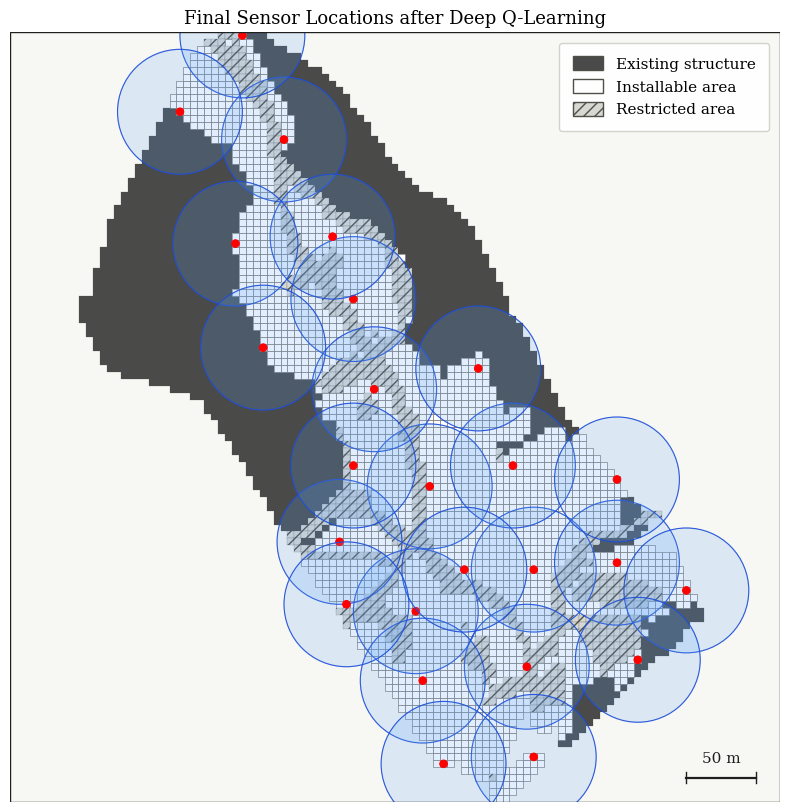

Saved figure: __RESULTS__/_plots/06-19-13-42/[DRL]final_result.png


In [6]:
final_result = optimized_result + corner_candidate
print("Total number of Sensor:", len(final_result))
vis.showMap_circle(
    map_data=map_data,
    sensor_positions=final_result,
    title="Final Sensor Locations after Deep Q-Learning",
    radius=COVERAGE,
    cmap="gray",
    filename="[DRL]final_result"
)